# 06. Fairness

The question is **not** whether the participants preferred their own background. They did, it is in
the data, and it is descriptive. The question is whether **the engine** disadvantages a group.

| Symbol | Here |
|---|---|
| Y = 1 | the pair matched |
| Ŷ = 1 | the pair is in the top decile, so the app would show it |
| D | the protected attribute, D = 1 the protected group |

**Two definitions of D**, treated separately: a person's **ethnicity**, one group against all others,
on the 8,368 person-pair rows; and a **mixed pair** against a same-background pair, on the 4,184
pairs.

Six sections, each ending with what it says and what to conclude.

1. Statistical parity
2. Conditional parity, and the verdict
3. Amplification
4. Mitigation, and why removing the column fails
5. Equal opportunity and calibration
6. Equivalence

In [1]:
%matplotlib inline

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.contingency_tables import StratifiedTable
from statsmodels.stats.multitest import multipletests
from xgboost import XGBClassifier

if not Path("data").is_dir():
    os.chdir("..")

Path("reports/figures").mkdir(parents=True, exist_ok=True)
Path("reports/tables").mkdir(parents=True, exist_ok=True)

SEED, K, ALPHA = 42, 0.10, 0.05
RACE = {1: "Black", 2: "White", 3: "Latino", 4: "Asian", 5: "Native American", 6: "Other"}

table = pd.read_csv("data/processed/model_table.csv")
oof = pd.read_csv("data/processed/oof_predictions.csv")

MODEL = "logit"          # the two-stage white box, our recommended model
oof["shown"] = (oof[MODEL] >= oof[MODEL].quantile(1 - K)).astype(int)
print(f"{oof.shown.sum()} pairs shown out of {len(oof)}; {oof.match.mean():.3f} base match rate")

419 pairs shown out of 4184; 0.165 base match rate


In [2]:
# One row per participant per date: the unit for anything defined on a person's ethnicity.
sides = pd.concat([
    pd.DataFrame({"pair": table.pair, "wave": table.wave, "match": table.match,
                  "shown": oof.shown, "race": table.her_race, "female": 1}),
    pd.DataFrame({"pair": table.pair, "wave": table.wave, "match": table.match,
                  "shown": oof.shown, "race": table.his_race, "female": 0})], ignore_index=True)
sides["group"] = sides.race.map(RACE)
sides = sides.dropna(subset=["group"])

GROUPS = sides.group.value_counts()
print(GROUPS.to_string())
print(f"\n{len(sides)} person-pair rows, {int(2 * len(table)) - len(sides)} dropped for a missing ethnicity")

group
White     4722
Asian     1978
Latino     664
Other      521
Black      420

8305 person-pair rows, 63 dropped for a missing ethnicity


Five groups, and nothing like the same size. A test on the small ones has little power, so a
non-significant result there means "we cannot tell", not "there is no gap". Every table carries the
group size for that reason.

## 1. Statistical parity

Pr(Ŷ = 1 | D = 1) = Pr(Ŷ = 1 | D = 0), tested group against all others with a two-proportion z-test.

In [3]:
def two_proportion_z(shown_a, n_a, shown_b, n_b):
    # Pooled variance, the usual form for a difference of proportions under the null.
    p_a, p_b = shown_a / n_a, shown_b / n_b
    pooled = (shown_a + shown_b) / (n_a + n_b)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n_a + 1 / n_b))
    z = (p_a - p_b) / se
    return p_a, p_b, z, 2 * stats.norm.sf(abs(z))

rows = []
for group in GROUPS.index:
    inside, outside = sides[sides.group == group], sides[sides.group != group]
    rate, other, z, p = two_proportion_z(inside.shown.sum(), len(inside),
                                         outside.shown.sum(), len(outside))
    rows.append({"group": group, "n": len(inside), "selection rate": rate,
                 "rate elsewhere": other, "difference (pts)": 100 * (rate - other), "z": z, "p-value": p})

parity = pd.DataFrame(rows).set_index("group").sort_values("difference (pts)")
parity.round(4)

,n,selection rate,rate elsewhere,difference (pts),z,p-value
group,,,,,,
Asian,1978,0.0576,0.1128,-5.5216,-7.1543,0.0000
White,4722,0.0972,0.1030,-0.5782,-0.8710,0.3837
Latino,664,0.1310,0.0970,3.4047,2.8089,0.0050
Other,521,0.1651,0.0953,6.9743,5.1442,0.0000
Black,420,0.1952,0.0946,10.0628,6.7071,0.0000


In [4]:
mixed = table.samerace == 0
rate, other, z, p = two_proportion_z(oof.shown[mixed].sum(), int(mixed.sum()),
                                     oof.shown[~mixed].sum(), int((~mixed).sum()))
pair_parity = pd.DataFrame([{"comparison": "mixed pair vs same background", "n mixed": int(mixed.sum()),
                             "selection rate, mixed": rate, "selection rate, same": other,
                             "difference (pts)": 100 * (rate - other), "z": z, "p-value": p}]).set_index("comparison")
pair_parity.round(4)

,n mixed,"selection rate, mixed","selection rate, same",difference (pts),z,p-value
comparison,,,,,,
mixed pair vs same background,2526,0.0871,0.12,-3.293,-3.4706,0.0005


**What it says.** The gaps are large and go both ways. Asian participants appear in 5.8% of the shown
pairs against 11.3% for everyone else, so they are recommended about half as often. Black participants
are at 19.5%. White participants sit at the average. Mixed pairs are shown 3.4 points less often than
same-background pairs.

**Conclusion so far: none.** A group can differ on things the engine is entitled to use. That is what
the next section separates.

## 2. Conditional parity

Ŷ ⊥ D | X_c, where X_c is the set of **legitimate** variables. We commit to four and defend them:

| Variable | Why it is legitimate |
|---|---|
| `other_selfattr` | how attractive the partner rates themselves, the thing a dating app exists to act on |
| `other_selfsinc` | sincerity, same argument |
| `interests` | how alike the two activity profiles are, a property of the pair |
| `agegap` | the age difference, which both sides state a preference over |

The four are combined into one score, cut into four strata of equal size, and the Cochran, Mantel and
Haenszel test asks whether D and Ŷ are still associated **inside** the strata.

In [5]:
LEGITIMATE = ["other_selfattr", "other_selfsinc", "interests", "agegap"]

legitimate_model = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                                 LogisticRegression(max_iter=3000))
pair_legitimate = pd.DataFrame({
    "other_selfattr": table[["her_selfattr", "his_selfattr"]].mean(axis=1),
    "other_selfsinc": table[["her_selfsinc", "his_selfsinc"]].mean(axis=1),
    "interests": table.interests, "agegap": table.agegap})
legitimate_model.fit(pair_legitimate, table.match)
pair_stratum = pd.qcut(legitimate_model.predict_proba(pair_legitimate)[:, 1], 4, labels=False)
stratum = pd.concat([pd.Series(pair_stratum)] * 2, ignore_index=True)[sides.index]

print("pairs per stratum:", np.bincount(pair_stratum))
print("match rate per stratum:", table.groupby(pair_stratum).match.mean().round(3).to_list())

pairs per stratum: [1046 1046 1046 1046]
match rate per stratum: [0.12, 0.157, 0.166, 0.216]


In [6]:
def cochran_mantel_haenszel(flag, shown, strata):
    # One 2x2 table of (in the group / not) x (shown / not) per stratum, then the CMH test.
    tables = []
    for s in np.unique(strata):
        here = strata == s
        tables.append(np.array([[int(((flag == 1) & (shown == 1) & here).sum()),
                                 int(((flag == 1) & (shown == 0) & here).sum())],
                                [int(((flag == 0) & (shown == 1) & here).sum()),
                                 int(((flag == 0) & (shown == 0) & here).sum())]]))
    result = StratifiedTable(tables)
    return result.oddsratio_pooled, result.test_null_odds().pvalue

rows = []
for group in GROUPS.index:
    ratio, p = cochran_mantel_haenszel((sides.group == group).to_numpy(), sides.shown.to_numpy(),
                                       stratum.to_numpy())
    rows.append({"D": group, "common odds ratio": ratio, "CMH p-value": p})
ratio, p = cochran_mantel_haenszel(mixed.to_numpy().astype(int), oof.shown.to_numpy(), pair_stratum)
rows.append({"D": "mixed pair", "common odds ratio": ratio, "CMH p-value": p})

conditional = pd.DataFrame(rows).set_index("D")
conditional.round(4)

,common odds ratio,CMH p-value
D,,
White,0.8827,0.0965
Asian,0.5374,0.0000
Latino,1.4508,0.0025
Other,1.7381,0.0000
Black,2.1216,0.0000
mixed pair,0.7007,0.0007


In [7]:
verdicts = pd.DataFrame({
    "n": list(parity.n) + [int(mixed.sum())],
    "difference (pts)": list(parity["difference (pts)"]) + [pair_parity["difference (pts)"].iloc[0]],
    "parity p": list(parity["p-value"]) + [pair_parity["p-value"].iloc[0]]},
    index=list(parity.index) + ["mixed pair"])
verdicts["conditional p"] = conditional["CMH p-value"].reindex(verdicts.index).to_numpy()

def traffic_light(row):
    raw, conditioned = row["parity p"] < ALPHA, row["conditional p"] < ALPHA
    if raw and conditioned:
        return "RED: the gap survives the legitimate variables"
    if raw:
        return "AMBER: explained by the legitimate variables"
    return "GREEN: no detectable gap"

verdicts["verdict"] = verdicts.apply(traffic_light, axis=1)
verdicts.to_csv("reports/tables/06_parity_verdicts.csv")
verdicts.round(4)

,n,difference (pts),parity p,conditional p,verdict
Asian,1978,-5.5216,0.0000,0.0000,RED: the gap survives the legitimate variables
White,4722,-0.5782,0.3837,0.0965,GREEN: no detectable gap
Latino,664,3.4047,0.0050,0.0025,RED: the gap survives the legitimate variables
Other,521,6.9743,0.0000,0.0000,RED: the gap survives the legitimate variables
Black,420,10.0628,0.0000,0.0000,RED: the gap survives the legitimate variables
mixed pair,2526,-3.2930,0.0005,0.0007,RED: the gap survives the legitimate variables


**What it says, and it is the answer to the client's question.** Four of the six gaps survive. Inside
strata of comparable attractiveness, sincerity, shared interests and age gap, an Asian participant
still has about half the odds of being recommended, common odds ratio 0.54, and a Black participant
about twice, 2.12. Mixed pairs stay at 0.69. Only White participants come out green, which is what a
majority group usually does.

**Conclusion.** It is not "the participants were biased and the model reflects it". The model produces
gaps the legitimate variables do not explain.

## 3. Amplification

**Our one addition to the course.** Parity asks whether a group is shown less. Amplification asks
whether the engine **exaggerates** a preference already in the data: the share of same-background
pairs among the pairs shown, divided by their share among the pairs that actually matched. Above 1,
the recommendation is more segregated than reality.

In [8]:
def amplification(frame, shown_column="shown"):
    same = table.samerace.to_numpy()[frame.index]
    shown, matched = frame[shown_column].to_numpy() == 1, frame.match.to_numpy() == 1
    return same[shown].mean() / same[matched].mean()

def bootstrap_ci(frame, metric, n_boot=1000, stratify_by="wave", seed=SEED):
    # Rows resampled within waves, the same function as in 04 and 05.
    rng = np.random.default_rng(seed)
    blocks = [g.index.to_numpy() for _, g in frame.groupby(stratify_by)]
    draws = [metric(frame.loc[np.concatenate([rng.choice(b, len(b), True) for b in blocks])])
             for _ in range(n_boot)]
    return metric(frame), *np.percentile(draws, [2.5, 97.5])

point, low, high = bootstrap_ci(oof, amplification)
print(f"same-background share among shown pairs:   {table.samerace[oof.shown == 1].mean():.3f}")
print(f"same-background share among matched pairs: {table.samerace[oof.match == 1].mean():.3f}")
print(f"amplification ratio: {point:.3f}   95% CI [{low:.3f}, {high:.3f}]")

same-background share among shown pairs:   0.475
same-background share among matched pairs: 0.410
amplification ratio: 1.158   95% CI [1.025, 1.294]


In [9]:
rows = []
for k in [0.05, 0.10, 0.20]:
    frame = oof.assign(shown=(oof[MODEL] >= oof[MODEL].quantile(1 - k)).astype(int))
    point, low, high = bootstrap_ci(frame, amplification, n_boot=500)
    rows.append({"shown": f"top {k:.0%}", "amplification": round(point, 3),
                 "95% CI": f"[{low:.3f}, {high:.3f}]",
                 "amplifies": "yes" if low > 1 else "not detectable"})

pd.DataFrame(rows).set_index("shown")

,amplification,95% CI,amplifies
shown,,,
top 5%,1.138,"[0.952, 1.319]",not detectable
top 10%,1.158,"[1.030, 1.284]",yes
top 20%,1.177,"[1.071, 1.292]",yes


**What it says.** Same-background pairs are 41% of the matches and 48% of the shortlist. The ratio is
**1.16, interval [1.03, 1.30]**. It grows with the length of the list and disappears into the noise at
the top 5%, where only 209 pairs are shown.

**Conclusion.** The engine did not invent a preference, it sharpened one. This is the number to put on
the slide.

The same two checks for all three engines, so 07 can compare them.

In [10]:
# The same checks for each engine, so the scorecard in 07 can compare them.
rows = []
for name in [c for c in ["logit", "xgboost", "tabpfn"] if c in oof.columns]:
    shown = (oof[name] >= oof[name].quantile(1 - K)).astype(int)
    person = pd.concat([shown, shown], ignore_index=True)[sides.index]
    gaps = {}
    for group in GROUPS.index:
        inside, outside = sides.group == group, sides.group != group
        rate, other, _, p = two_proportion_z(person[inside].sum(), inside.sum(),
                                             person[outside].sum(), outside.sum())
        gaps[group] = (100 * (rate - other), p)
    least = min(gaps, key=lambda g: gaps[g][0])
    most = max(gaps, key=lambda g: gaps[g][0])
    rows.append({"model": name,
                 "least recommended": least, "their gap (pts)": gaps[least][0],
                 "most recommended": most, "and theirs (pts)": gaps[most][0],
                 "amplification": amplification(oof.assign(shown=shown))})

by_model = pd.DataFrame(rows).set_index("model")
by_model.to_csv("reports/tables/06_by_model.csv")
by_model.round(3)

,least recommended,their gap (pts),most recommended,and theirs (pts),amplification
model,,,,,
logit,Asian,-5.522,Black,10.063,1.158
xgboost,Asian,-2.665,Black,11.266,1.013
tabpfn,Asian,-6.100,Other,6.117,1.274


**What it says, and it is not what we expected.** All three put Asian participants last, but by very
different margins: 2.7 points below everyone else for XGBoost, 5.5 for the logistic regression, 6.1
for TabPFN. Amplification follows the same order, **1.01 for XGBoost against 1.27 for TabPFN**.

**Conclusion.** Fairness separates the engines where performance could not, and it does not favour the
model we were going to recommend. It is also a warning against reading one model's amplification as a
property of the data: the same target and the same columns give 1.01 or 1.27 depending on the model.

## 4. Mitigation

Four models refitted on the same folds with the same pipeline, differing only in what they may see
about ethnicity. **Panel A** refits. **Panel B** keeps the full model and neutralises the ethnicity
columns at prediction time, which is what a team would do if retraining were not an option.

In [11]:
TARGETS = ["pair", "wave", "match", "fold", "her_dec", "his_dec"]
SIDE_CATEGORICAL = ["self_field", "self_race", "self_goal", "other_field", "other_race", "other_goal"]

def decision_view(tab, decider, drop=()):
    mine, theirs = ("her", "his") if decider == "her" else ("his", "her")
    view = tab.drop(columns=TARGETS).rename(
        columns=lambda c: c.replace(f"{mine}_", "self_").replace(f"{theirs}_", "other_"))
    view["agediff"] = view.self_age - view.other_age
    view["female"] = int(decider == "her")
    return view.drop(columns=[c for c in drop if c in view.columns])

def two_stage(categorical):
    encode = ColumnTransformer(
        [("categories", OneHotEncoder(min_frequency=0.03, handle_unknown="infrequent_if_exist",
                                      sparse_output=False), categorical)], remainder="passthrough")
    return make_pipeline(encode, SimpleImputer(strategy="median"), StandardScaler(),
                         LogisticRegression(max_iter=3000, C=0.05, l1_ratio=1, solver="liblinear"))

VARIANTS = {
    "full model": (),
    "without raceclash": ("raceclash",),
    "without ethnicity": ("self_race", "other_race"),
    "without either": ("self_race", "other_race", "raceclash"),
    "unawareness": ("self_race", "other_race", "raceclash", "samerace",
                    "self_racepref", "other_racepref", "racepref_max")}

def refit_scores(drop):
    hers, his = decision_view(table, "her", drop), decision_view(table, "his", drop)
    categorical = [c for c in SIDE_CATEGORICAL if c in hers.columns]
    scores = np.empty(len(table))
    for k in sorted(table.fold.unique()):
        train, test = (table.fold != k).to_numpy(), (table.fold == k).to_numpy()
        model = two_stage(categorical).fit(
            pd.concat([hers[train], his[train]], ignore_index=True),
            pd.concat([table.her_dec[train], table.his_dec[train]], ignore_index=True))
        scores[test] = (model.predict_proba(hers[test])[:, 1] * model.predict_proba(his[test])[:, 1])
    return scores

In [12]:
def group_parity(shown):
    # Selection rate of each ethnic group against the rest, on the person-pair rows.
    person = pd.concat([pd.Series(shown)] * 2, ignore_index=True)[sides.index]
    out = {}
    for group in GROUPS.index:
        inside, outside = person[sides.group == group], person[sides.group != group]
        out[group] = two_proportion_z(inside.sum(), len(inside), outside.sum(), len(outside))[3]
    return pd.Series(out)

def evaluate(scores, k=K):
    shown = (scores >= np.quantile(scores, 1 - k)).astype(int)
    by_group = group_parity(shown)
    _, _, _, p_mixed = two_proportion_z(shown[mixed].sum(), int(mixed.sum()),
                                        shown[~mixed].sum(), int((~mixed).sum()))
    return {"worst group": by_group.idxmin(), "parity p (that group)": by_group.min(),
            "parity p (mixed pairs)": p_mixed,
            "amplification": amplification(oof.assign(shown=shown)),
            "PR-AUC": average_precision_score(table.match, scores),
            "top decile": table.match[scores >= np.quantile(scores, 0.9)].mean()}

panel_a = pd.DataFrame({name: evaluate(refit_scores(drop)) for name, drop in VARIANTS.items()}).T
panel_a.index.name = "Panel A, refitted"
panel_a.round(4)

,worst group,parity p (that group),parity p (mixed pairs),amplification,PR-AUC,top decile
"Panel A, refitted",,,,,,
full model,Asian,0.0,0.000519,1.157982,0.228165,0.298329
without raceclash,Asian,0.0,0.000002,1.22781,0.222322,0.279236
without ethnicity,White,0.0,0.0,1.350009,0.218607,0.250597
without either,White,0.000006,0.0,1.291819,0.21656,0.252983
unawareness,White,0.008855,0.058591,1.070697,0.210344,0.24821


In [13]:
hers_full, his_full = decision_view(table, "her"), decision_view(table, "his")

def neutralised(frame, what):
    # No refit: the model still has its ethnicity coefficients, we just feed it a neutral profile.
    out = frame.copy()
    if "race" in what:
        out["self_race"] = out["other_race"] = 2.0          # the majority category
    if "raceclash" in what:
        out["raceclash"] = 0.0
    return out

def blind_scores(what):
    scores = np.empty(len(table))
    for k in sorted(table.fold.unique()):
        train, test = (table.fold != k).to_numpy(), (table.fold == k).to_numpy()
        model = two_stage(SIDE_CATEGORICAL).fit(
            pd.concat([hers_full[train], his_full[train]], ignore_index=True),
            pd.concat([table.her_dec[train], table.his_dec[train]], ignore_index=True))
        scores[test] = (model.predict_proba(neutralised(hers_full[test], what))[:, 1]
                        * model.predict_proba(neutralised(his_full[test], what))[:, 1])
    return scores

PANEL_B = {"full model": (), "ethnicity neutralised": ("race",),
           "raceclash neutralised": ("raceclash",), "both neutralised": ("race", "raceclash")}
panel_b = pd.DataFrame({name: evaluate(blind_scores(what)) for name, what in PANEL_B.items()}).T
panel_b.index.name = "Panel B, neutralised, no refit"
pd.concat([panel_a, panel_b]).to_csv("reports/tables/06_mitigation.csv")
panel_b.round(4)

,worst group,parity p (that group),parity p (mixed pairs),amplification,PR-AUC,top decile
"Panel B, neutralised, no refit",,,,,,
full model,Asian,0.0,0.000153,1.175439,0.226587,0.300716
ethnicity neutralised,White,0.0,0.0,1.565312,0.214725,0.24821
raceclash neutralised,Black,0.0,0.000339,0.768108,0.224688,0.279236
both neutralised,White,0.008951,0.011636,1.105611,0.213736,0.25537


**What it says, and this is the most useful result in the notebook.** Removing ethnicity makes the
segregation **worse**: amplification goes from 1.16 to 1.35 refitted, and to 1.57 neutralised without
a refit. Deprived of the column the model leans harder on whatever correlates with it, and pays five
points of top-decile match rate for the privilege.

Only the full unawareness variant moves the needle, dropping ethnicity, `raceclash`, `samerace` and
both preference columns at once: amplification falls to 1.07 and the mixed-pair gap stops being
significant. It costs the most performance of any variant.

**Conclusion.** The trade-off to hand the client: about five points of top-decile match rate in
exchange for a recommendation that no longer sharpens the same-background preference.

And the price in the client's own units.

In [14]:
mitigated = refit_scores(VARIANTS["unawareness"])
full = refit_scores(VARIANTS["full model"])
per_thousand = lambda s: 1000 * table.match[s >= np.quantile(s, 1 - K)].mean()
print(f"full model:     {per_thousand(full):.0f} matches per 1,000 recommendations")
print(f"unawareness:    {per_thousand(mitigated):.0f}")
print(f"price of removing the amplification: {per_thousand(full) - per_thousand(mitigated):.0f} "
      f"matches per 1,000, or that many times the value of one match")

full model:     298 matches per 1,000 recommendations
unawareness:    248
price of removing the amplification: 50 matches per 1,000, or that many times the value of one match


### Why removing the column is not enough

Fairness through unawareness assumes a model that never sees ethnicity cannot act on it. The test is
direct: try to predict ethnicity from everything that is left.

In [15]:
left = decision_view(table, "her", VARIANTS["unawareness"])
target = table.her_race.notna()
proxy = make_pipeline(
    ColumnTransformer([("categories", OneHotEncoder(min_frequency=0.03,
                        handle_unknown="infrequent_if_exist", sparse_output=False),
                        [c for c in SIDE_CATEGORICAL if c in left.columns])], remainder="passthrough"),
    SimpleImputer(strategy="median"), StandardScaler(), LogisticRegression(max_iter=3000))

recovered = []
for group in GROUPS.index:
    y = (table.her_race.map(RACE) == group).astype(int)[target]
    scores = np.empty(int(target.sum()))
    folds = table.fold[target].to_numpy()
    for k in np.unique(folds):
        train, test = folds != k, folds == k
        proxy.fit(left[target][train], y[train])
        scores[test] = proxy.predict_proba(left[target][test])[:, 1]
    recovered.append({"group": group, "share": y.mean(),
                      "AUC predicting it without any ethnicity column": roc_auc_score(y, scores)})

recovered = pd.DataFrame(recovered).set_index("group")
recovered.to_csv("reports/tables/06_proxy_recovery.csv")
recovered.round(3)

,share,AUC predicting it without any ethnicity column
group,,
White,0.533,0.651
Asian,0.252,0.664
Latino,0.097,0.510
Other,0.059,0.469
Black,0.058,0.516


**What it says.** Ethnicity is recoverable at **AUC 0.66** for White and Asian participants from a
table with no ethnicity column, no `samerace`, no `raceclash` and no preference for background. Income
missingness, going-out habits and self-rated looks carry it. For the three small groups the AUC is
near 0.5, which is a statement about 420 rows rather than the absence of a proxy.

**Conclusion.** Unawareness is not a defence. The model can act on ethnicity without being shown it,
which is exactly what the amplification number shows it doing.

## 5. Equal opportunity and calibration

Equal opportunity is Ŷ ⊥ D | Y: among the pairs that **did** match, is the engine as likely to have
shown them for one group as for another? That is the error the client pays for, a real match the app
never surfaced.

In [16]:
matched = sides[sides.match == 1]
rows = []
for group in GROUPS.index:
    inside, outside = matched[matched.group == group], matched[matched.group != group]
    rate, other, z, p = two_proportion_z(inside.shown.sum(), len(inside), outside.shown.sum(), len(outside))
    rows.append({"group": group, "matches in the data": len(inside),
                 "share of them shown": rate, "elsewhere": other,
                 "difference (pts)": 100 * (rate - other), "p-value": p})

opportunity = pd.DataFrame(rows).set_index("group").sort_values("difference (pts)")
opportunity.to_csv("reports/tables/06_equal_opportunity.csv")
opportunity.round(4)

,matches in the data,share of them shown,elsewhere,difference (pts),p-value
group,,,,,
Asian,267,0.1049,0.2011,-9.6223,0.0003
White,788,0.1612,0.2111,-4.9905,0.0183
Latino,123,0.2195,0.1786,4.0912,0.2623
Black,85,0.3412,0.1717,16.9436,0.0001
Other,103,0.3689,0.1671,20.1869,0.0000


**What it says, and this is the number to say out loud.** Among the pairs that really matched, the app
would have surfaced **10.5% of the Asian ones against 20.1% for everyone else**, and 36.9% of the
"Other" ones.

**Conclusion.** The engine is not merely showing some groups less, it is missing their real matches at
twice the rate. Equal opportunity fails where parity already failed, and in the same direction, so the
two diagnoses agree.

Calibration checks something else: when the engine says 30%, is it 30% for everyone?

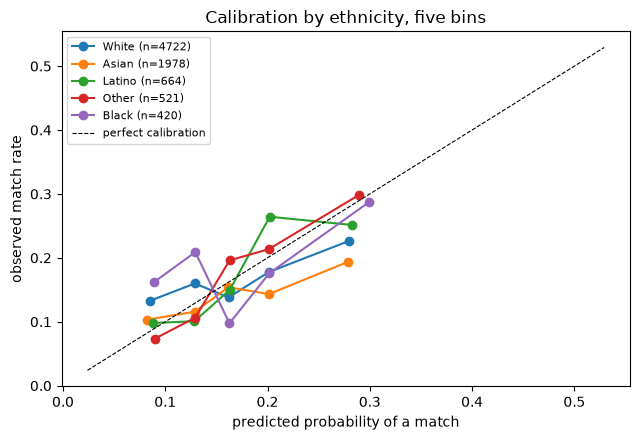

In [17]:
person_score = pd.concat([oof[MODEL], oof[MODEL]], ignore_index=True)[sides.index]
bins = pd.qcut(person_score, 5, labels=False)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for group in GROUPS.index:
    here = sides.group == group
    ax.plot(person_score[here].groupby(bins[here]).mean(),
            sides.match[here].groupby(bins[here]).mean(), "o-", label=f"{group} (n={GROUPS[group]})")
limits = [person_score.min(), person_score.max()]
ax.plot(limits, limits, "k--", linewidth=0.8, label="perfect calibration")
ax.set_xlabel("predicted probability of a match")
ax.set_ylabel("observed match rate")
ax.set_title("Calibration by ethnicity, five bins")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("reports/figures/06_calibration.png", dpi=150)
plt.show()

**What it says.** The curves sit close to the diagonal for the two large groups and wander for the
small ones, which is what 420 rows look like.

**Conclusion.** The scores mean roughly the same thing across groups. The problem is not that the
engine is miscalibrated, it is where it places the cut.

## 6. Equivalence

A non-significant difference is not evidence of equality; it can simply mean a small sample. The two
one-sided tests reverse the null: it becomes "the gap is **at least** δ", and rejecting it on both
sides is evidence the gap is smaller than δ.

z^L = (p̂₁ − p̂₂ + δ) / σ̂, with σ̂² = p̂₁(1−p̂₁)/n₁ + p̂₂(1−p̂₂)/n₂, unpooled because under the
equivalence null the two proportions are not assumed equal.

**We set δ = 5 percentage points** of selection rate. The four-fifths rule puts a group at 8% against a
10% overall rate at the edge of adverse impact, so 5 points is beyond it, and anything under about 3
points is smaller than the noise on our own estimates. δ = 3 and δ = 10 are reported alongside.

In [18]:
def tost(shown_a, n_a, shown_b, n_b, delta, alpha=ALPHA):
    p_a, p_b = shown_a / n_a, shown_b / n_b
    se = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)   # unpooled
    z_low, z_high = (p_a - p_b + delta) / se, (p_a - p_b - delta) / se
    critical = stats.t.ppf(1 - alpha, n_a + n_b - 2)
    return z_low, z_high, (z_low > critical) and (z_high < -critical)

rows = []
for delta in [0.03, 0.05, 0.10]:
    for group in GROUPS.index:
        inside, outside = sides[sides.group == group], sides[sides.group != group]
        z_low, z_high, equivalent = tost(inside.shown.sum(), len(inside),
                                         outside.shown.sum(), len(outside), delta)
        rows.append({"delta": f"{delta:.0%}", "D": group, "n": len(inside),
                     "z lower": z_low, "z upper": z_high,
                     "equivalent": "yes" if equivalent else "cannot conclude"})
    z_low, z_high, equivalent = tost(oof.shown[mixed].sum(), int(mixed.sum()),
                                     oof.shown[~mixed].sum(), int((~mixed).sum()), delta)
    rows.append({"delta": f"{delta:.0%}", "D": "mixed pair", "n": int(mixed.sum()),
                 "z lower": z_low, "z upper": z_high,
                 "equivalent": "yes" if equivalent else "cannot conclude"})

equivalence = pd.DataFrame(rows).set_index(["delta", "D"])
equivalence.to_csv("reports/tables/06_equivalence.csv")
equivalence.round(3)

n  z lower  z upper       equivalent
delta D                                                  
3%    White       4722    3.636   -5.372              yes
      Asian       1978   -3.833  -12.953  cannot conclude
      Latino       664    4.735    0.299  cannot conclude
      Other        521    6.008    2.394  cannot conclude
      Black        420    6.658    3.600  cannot conclude
      mixed pair  2526   -0.300   -6.450  cannot conclude
5%    White       4722    6.638   -8.375              yes
      Asian       1978   -0.793  -15.993  cannot conclude
      Latino       664    6.214   -1.179  cannot conclude
      Other        521    7.213    1.189  cannot conclude
      Black        420    7.677    2.580  cannot conclude
      mixed pair  2526    1.750   -8.500              yes
10%   White       4722   14.145  -15.881              yes
      Asian       1978    6.807  -23.593              yes
      Latino       664    9.911   -4.876              yes
      Other        521   10.225   -1.823              yes
      Black        420   10.225    0.032  cannot conclude
      mixed pair  2526    6.875  -13.626              yes

**What it says.** Only White participants are equivalent at δ = 3, and only White and mixed pairs at
δ = 5. For the three small groups the test cannot conclude below 10 points.

**Conclusion.** For Latino, Black and "Other" participants we can neither show a gap nor certify its
absence. That is an absence of power, not a clean bill of health, and the client should be told to
re-run this check once the app has more users.

## What goes on the slide

In [19]:
print(verdicts[["difference (pts)", "parity p", "conditional p", "verdict"]].round(4).to_string())
point, low, high = bootstrap_ci(oof, amplification)
print(f"\namplification, {MODEL}: {point:.2f} [{low:.2f}, {high:.2f}]")
print(f"the same for every engine:\n{by_model[['least recommended', 'amplification']].round(3).to_string()}")
print(f"\nremoving ethnicity and raceclash: top decile "
      f"{panel_a.loc['full model', 'top decile']:.3f} -> {panel_a.loc['without either', 'top decile']:.3f}")
print(f"ethnicity stays recoverable without any ethnicity column, up to AUC "
      f"{recovered['AUC predicting it without any ethnicity column'].max():.2f}")
print(f"equivalent at 5 points: {(equivalence.loc['5%', 'equivalent'] == 'yes').sum()} "
      f"of {len(GROUPS) + 1} comparisons")

            difference (pts)  parity p  conditional p                                         verdict
Asian                -5.5216    0.0000         0.0000  RED: the gap survives the legitimate variables
White                -0.5782    0.3837         0.0965                        GREEN: no detectable gap
Latino                3.4047    0.0050         0.0025  RED: the gap survives the legitimate variables
Other                 6.9743    0.0000         0.0000  RED: the gap survives the legitimate variables
Black                10.0628    0.0000         0.0000  RED: the gap survives the legitimate variables
mixed pair           -3.2930    0.0005         0.0007  RED: the gap survives the legitimate variables



amplification, logit: 1.16 [1.03, 1.29]
the same for every engine:
        least recommended  amplification
model                                   
logit               Asian          1.158
xgboost             Asian          1.013
tabpfn              Asian          1.274

removing ethnicity and raceclash: top decile 0.298 -> 0.253
ethnicity stays recoverable without any ethnicity column, up to AUC 0.66
equivalent at 5 points: 2 of 6 comparisons
